In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('sales.csv')

print("Missing values per column:")
print(df.isnull().sum())



Missing values per column:
sale_id             0
branch              0
city                0
customer_type       0
gender              0
product_name        0
product_category    0
unit_price          0
quantity            0
tax                 0
total_price         0
reward_points       0
dtype: int64


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   object 
 2   city              1000 non-null   object 
 3   customer_type     1000 non-null   object 
 4   gender            1000 non-null   object 
 5   product_name      1000 non-null   object 
 6   product_category  1000 non-null   object 
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.9+ KB
None


In [ ]:
calculated_total = (df['unit_price'] * df['quantity']) + df['tax']
mismatches = np.sum(np.abs(df['total_price'] - calculated_total) > 0.01)
print(f"Number of rows with pricing mismatches: {mismatches}")

duplicate_count = df.duplicated(subset=df.columns[1:]).sum()
print(f"Number of duplicate records found: {duplicate_count}")

Number of rows with pricing mismatches: 0
Number of duplicate records found: 0


In [ ]:
print("--- Numerical Column Summary ---")
print(df[['unit_price', 'quantity', 'tax', 'total_price', 'reward_points']].describe())

total_revenue = df['total_price'].sum()
total_units = df['quantity'].sum()
average_order_value = df['total_price'].mean()
print("\n--- Executive Business KPIs ---")
print(f"Total Revenue Generated: ${total_revenue:,.2f}")
print(f"Total Units Sold: {total_units:,} units")
print(f"Average Order Value (AOV): ${average_order_value:.2f}")

--- Numerical Column Summary ---
        unit_price     quantity          tax  total_price  reward_points
count  1000.000000  1000.000000  1000.000000  1000.000000    1000.000000
mean     10.836110    10.337000     7.758010   118.583900       6.057000
std       5.775924     6.029908     6.538066    99.936441       9.350464
min       1.020000     1.000000     0.080000     1.210000       0.000000
25%       5.867500     5.000000     2.510000    38.380000       0.000000
50%      10.615000    10.000000     5.870000    89.705000       0.000000
75%      15.882500    16.000000    11.522500   176.072500      10.000000
max      20.980000    20.000000    28.390000   433.990000      43.000000

--- Executive Business KPIs ---
Total Revenue Generated: $118,583.90
Total Units Sold: 10,337 units
Average Order Value (AOV): $118.58


In [ ]:
category_perf = df.groupby('product_category').agg(total_revenue=('total_price', 'sum'),
average_unit_price=('unit_price', 'mean'),units_sold=('quantity', 'sum')).sort_values(by='total_revenue', ascending=False)
print("--- Product Category Performance ---")
print(category_perf)


gender_customer_pivot = pd.pivot_table(df, values='total_price', index='customer_type', columns='gender', aggfunc='mean')
print("\n--- Average Transaction Amount ($) Matrix ---")
print(gender_customer_pivot)

--- Product Category Performance ---
                  total_revenue  average_unit_price  units_sold
product_category                                               
Personal Care          27050.18           11.246923        2278
Fruits                 26197.45           10.845263        2286
Beverages              22983.32           11.113155        1952
Household              21615.84           10.930707        1908
Stationery             20737.11           10.038636        1913

--- Average Transaction Amount ($) Matrix ---
gender             Female        Male
customer_type                        
Member         122.726706  122.297348
Normal         106.083273  121.333144


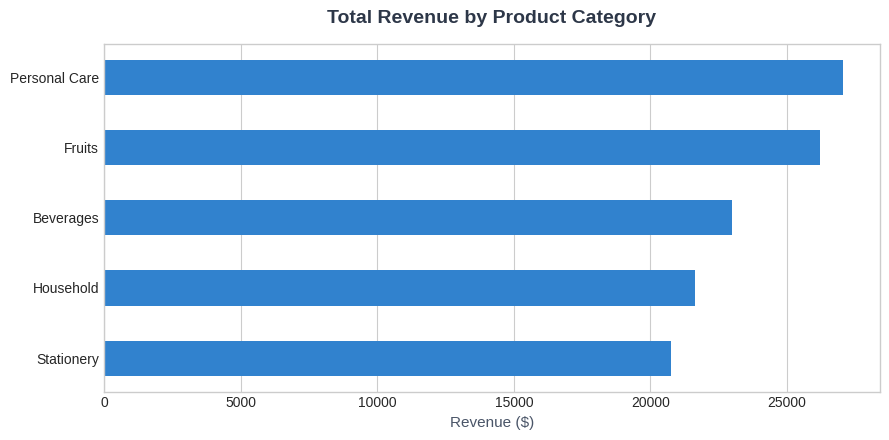

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

category_revenue = df.groupby('product_category')['total_price'].sum().sort_values()
plt.figure(figsize=(9, 4.5))
plt.barh(category_revenue.index, category_revenue.values, color='#3182ce', height=0.5)
plt.title('Total Revenue by Product Category', fontsize=14, pad=15, weight='bold', color='#2d3748')
plt.xlabel('Revenue ($)', fontsize=11, color='#4a5568')
plt.grid(axis='y', linestyle='')
plt.tight_layout()
plt.show()

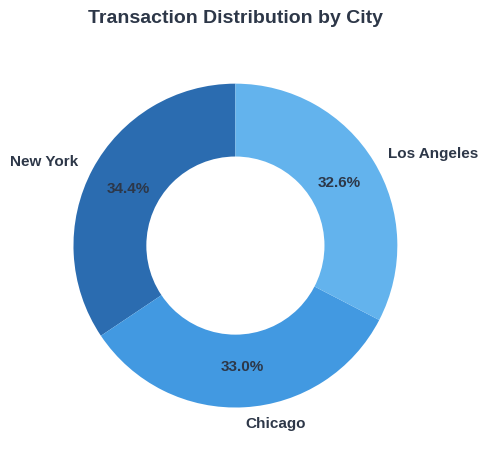

In [ ]:
city_counts = df['city'].value_counts()
plt.figure(figsize=(5, 5))
colors = ['#2b6cb0', '#4299e1', '#63b3ed']
plt.pie(city_counts.values, labels=city_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, pctdistance=0.75,
textprops={'fontsize': 11, 'color': '#2d3748', 'weight': 'bold'})
centre_circle = plt.Circle((0,0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Transaction Distribution by City', fontsize=14, pad=15, weight='bold', color='#2d3748')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1492/987904063.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([member_spend, normal_spend], labels=['Loyalty Member', 'Normal Customer'], patch_artist=True, widths=0.35,


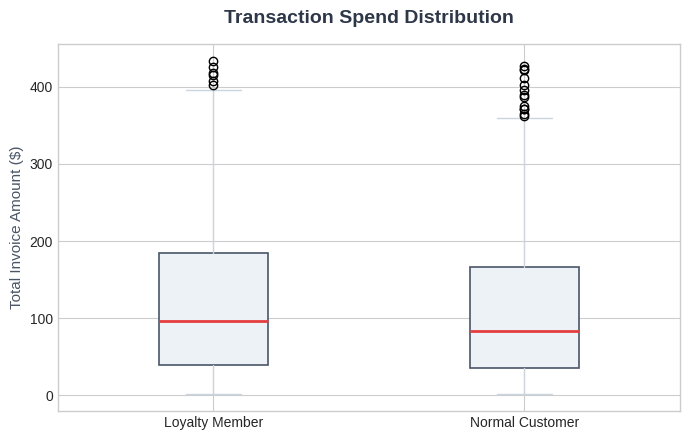

In [ ]:
member_spend = df[df['customer_type'] == 'Member']['total_price']
normal_spend = df[df['customer_type'] == 'Normal']['total_price']
plt.figure(figsize=(7, 4.5))
plt.boxplot([member_spend, normal_spend], labels=['Loyalty Member', 'Normal Customer'], patch_artist=True, widths=0.35,
boxprops=dict(facecolor='#edf2f7', color='#4a5568', linewidth=1.2),medianprops=dict(color='#e53e3e', linewidth=2),
whiskerprops=dict(color='#cbd5e0'),capprops=dict(color='#cbd5e0'))

plt.title('Transaction Spend Distribution', fontsize=14, pad=15, weight='bold', color='#2d3748')
plt.ylabel('Total Invoice Amount ($)', fontsize=11, color='#4a5568')
plt.tight_layout()
plt.show()

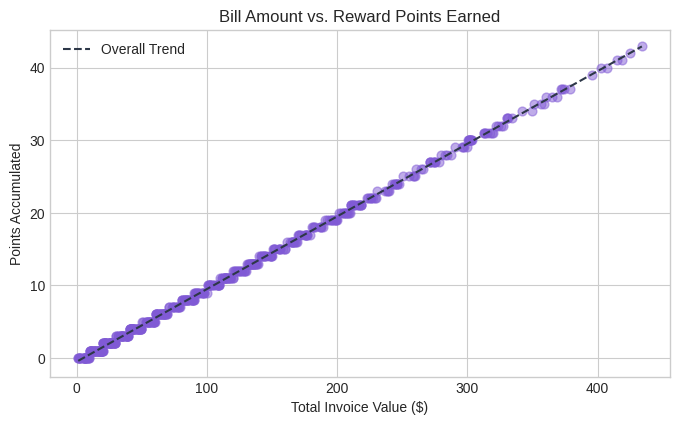

In [ ]:
members_only = df[df['customer_type'] == 'Member']
ax = members_only.plot.scatter(x='total_price', y='reward_points', color='#805ad5', alpha=0.5, s=40,figsize=(8, 4.5),
title='Bill Amount vs. Reward Points Earned')
trend = np.poly1d(np.polyfit(members_only['total_price'], members_only['reward_points'], 1))
x_vals = np.sort(members_only['total_price'])
ax.plot(x_vals, trend(x_vals), color='#2d3748', linestyle='--', label='Overall Trend')
ax.set_xlabel('Total Invoice Value ($)')
ax.set_ylabel('Points Accumulated')
ax.legend()
plt.show()